# Day 8 of ML 30-Days Challenge

# Task

**Feature Scaling**: Understand StandardScaler and MinMaxScaler. Learn why scaling is critical for distance-based algorithms (like SVM and K-NN) and how it helps gradient-based optimization algorithms converge faster.

## 1. Setup and Baseline Visualization

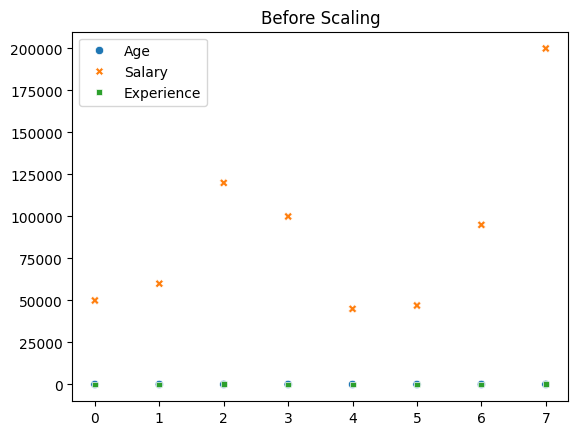

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame
data = {
    'Age': [25, 30, 45, 35, 22, 23, 40, 60],
    'Salary': [50000, 60000, 120000, 100000, 45000, 47000, 95000, 200000],
    'Experience': [1, 3, 20, 10, 0, 0, 12, 30]
}
df = pd.DataFrame(data)

# Visualize original (unscaled) data
sns.scatterplot(data=df)
plt.title("Before Scaling")
plt.show()

# let me educate you : scaling means making multiple dissimilar ranged data in similar ranged data
# see that 100000, 50000 values and there is 1, 3 -> its not fair and scaling is what makes them fair

## 2. Implementing StandardScaler (Z-score scaling)

In [27]:
from sklearn.preprocessing import StandardScaler

# Create scaler instance
standard_scaler = StandardScaler()

# Fit on training data
X_train = df[['Age', 'Salary', 'Experience']]
standard_scaler.fit(X_train)

# Transform train and test data (using train itself here for simplicity)
X_train_scaled = standard_scaler.transform(X_train)

# Convert back to DataFrame
df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(df_scaled.describe())

                Age        Salary  Experience
count  8.000000e+00  8.000000e+00    8.000000
mean   2.775558e-17  2.775558e-17    0.000000
std    1.069045e+00  1.069045e+00    1.069045
min   -1.066793e+00 -9.039191e-01   -0.931552
25%   -8.616404e-01 -8.178316e-01   -0.858008
50%   -2.051525e-01 -2.456027e-01   -0.294174
75%    5.128812e-01  3.114343e-01    0.441261
max    2.051525e+00  2.235744e+00    2.010190


## 3. Implementing MinMaxScaler (Normalization)

In [28]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler instance
min_max_scaler = MinMaxScaler()

# Fit and transform
X_minmax_scaled = min_max_scaler.fit_transform(X_train)

# Convert back to DataFrame
df_minmax = pd.DataFrame(X_minmax_scaled, columns=X_train.columns)
print(df_minmax.describe())

            Age    Salary  Experience
count  8.000000  8.000000    8.000000
mean   0.342105  0.287903    0.316667
std    0.342827  0.340497    0.363405
min    0.000000  0.000000    0.000000
25%    0.065789  0.027419    0.025000
50%    0.276316  0.209677    0.216667
75%    0.506579  0.387097    0.466667
max    1.000000  1.000000    1.000000


## 4. Visualizing Scaled Data

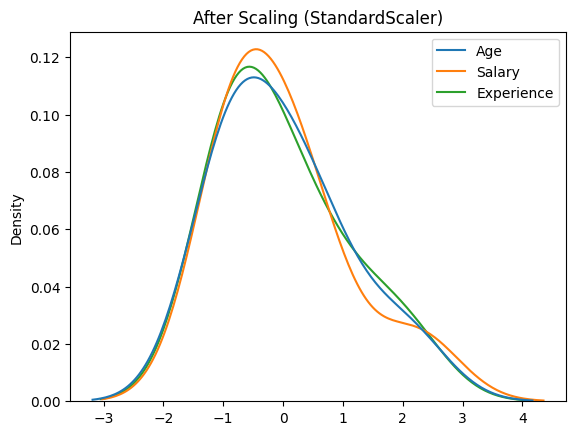

In [29]:
# Visualize scaled data (StandardScaler output here)
sns.kdeplot(data=df_scaled)
plt.title("After Scaling (StandardScaler)")
plt.show()

## 5. Demonstrating the Impact on a Model

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Simulate a target for demonstration
df['Target'] = [0, 1, 1, 1, 0, 0, 1, 1] # from 1st topic

# Split data
X = df[['Age', 'Salary', 'Experience']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Without scaling
model_unscaled = KNeighborsClassifier()
model_unscaled.fit(X_train, y_train)
y_pred_unscaled = model_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = KNeighborsClassifier()
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print("Accuracy without scaling:", acc_unscaled)
print("Accuracy with scaling:", acc_scaled)

Accuracy without scaling: 0.6666666666666666
Accuracy with scaling: 0.6666666666666666


## 6. Integrating Scaling into a Pipeline

In [31]:
from sklearn.pipeline import Pipeline

# Create pipeline with scaler and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

# Train and evaluate
pipeline.fit(X_train, y_train)
pipeline_accuracy = pipeline.score(X_test, y_test)
print("Pipeline model accuracy:", pipeline_accuracy)

Pipeline model accuracy: 0.6666666666666666
